reduce the effect of class imbalance  
improve minority class performance


In [1]:
from pathlib import Path
import sys

current_path = Path.cwd()

if current_path.name in ["notebook", "notebooks"]:
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "models").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("models exists:", (PROJECT_ROOT / "models").exists())
print("utils exists:", (PROJECT_ROOT / "utils").exists())



Current path: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\notebook
Project root: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1
models exists: True
utils exists: True


In [2]:
import importlib
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import utils.train_utils
importlib.reload(utils.train_utils)

from utils.dataset import get_dataloaders, print_dataset_info
from models.densenet import get_densenet121, count_trainable_parameters
from utils.train_utils import train_model, evaluate_model
from utils.metrics import print_metrics, get_confusion_matrix




In [3]:
EXPERIMENT_NAME = "densenet121_weighted_ce"

NUM_CLASSES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
MAX_EPOCHS = 30
PATIENCE = 7
MONITOR_METRIC = "qwk"

print("Experiment:", EXPERIMENT_NAME)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Max epochs:", MAX_EPOCHS)
print("Patience:", PATIENCE)
print("Monitor metric:", MONITOR_METRIC)


Experiment: densenet121_weighted_ce
Image size: 224
Batch size: 32
Learning rate: 0.0001
Max epochs: 30
Patience: 7
Monitor metric: qwk


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))



Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [5]:
SPLIT_ROOT = PROJECT_ROOT / "data" / "processed" / "split_images"

train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = get_dataloaders(
    split_root=SPLIT_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    use_augmentation=True,
)

print_dataset_info(train_dataset, val_dataset, test_dataset)

class_names = train_dataset.classes


Dataset Information
Train images: 1024
Val images:   146
Test images:  294

Class to index mapping:
{'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}

Classes:
['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']


In [6]:
model = get_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=0.3,
)

model = model.to(device)

trainable_params, total_params = count_trainable_parameters(model)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")


Trainable parameters: 6,958,981
Total parameters:     6,958,981


In [7]:
targets = np.array(train_dataset.targets)

class_counts = np.bincount(targets, minlength=NUM_CLASSES)

class_weights = class_counts.sum() / (NUM_CLASSES * class_counts)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class names:", class_names)
print("Class counts:", class_counts)
print("Class weights:", class_weights)
print("Class weights tensor:", class_weights_tensor)


Class names: ['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']
Class counts: [316 308 134 122 144]
Class weights: [0.64810127 0.66493506 1.52835821 1.67868852 1.42222222]
Class weights tensor: tensor([0.6481, 0.6649, 1.5284, 1.6787, 1.4222], device='cuda:0')


In [8]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


In [9]:
SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / f"{EXPERIMENT_NAME}.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=MAX_EPOCHS,
    save_path=SAVE_PATH,
    monitor_metric=MONITOR_METRIC,
    patience=PATIENCE,
    min_delta=1e-4,
)



Epoch 1/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 1.4427 | Train Acc: 0.3838 | Train Macro F1: 0.3615 | Train QWK: 0.4141
Val Loss:   1.0960 | Val Acc:   0.6027 | Val Macro F1: 0.5648 | Val QWK:   0.6810 | Val MAE:   0.6438
New best model found at epoch 1.
Best val qwk: 0.6810
Saved best model to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_weighted_ce.pth

Epoch 2/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.1484 | Train Acc: 0.9453 | Train Macro F1: 0.9444 | Train QWK: 0.9688
Val Loss:   0.6114 | Val Acc:   0.8082 | Val Macro F1: 0.7988 | Val QWK:   0.9153 | Val MAE:   0.2397
No improvement in val qwk. Patience: 6/7

Epoch 20/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.1407 | Train Acc: 0.9551 | Train Macro F1: 0.9530 | Train QWK: 0.9723
Val Loss:   0.6624 | Val Acc:   0.8425 | Val Macro F1: 0.8022 | Val QWK:   0.8979 | Val MAE:   0.2329
No improvement in val qwk. Patience: 7/7

Early stopping triggered
Best epoch: 13
Best val qwk: 0.9405


In [10]:
history_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

history_df.tail()


,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
15,16,0.160027,0.500314,13,2,0.935547,0.939691,0.935709,0.088867,0.961172,...,0.827932,0.839316,0.219178,0.905226,23,17,6,0.157534,0.116438,0.041096
16,17,0.129519,0.589910,13,3,0.942383,0.947682,0.942757,0.071289,0.974574,...,0.803377,0.818591,0.219178,0.915021,25,20,5,0.171233,0.136986,0.034247
17,18,0.161748,0.466364,13,4,0.940430,0.936997,0.940797,0.086914,0.959649,...,0.833828,0.833946,0.184932,0.939534,24,22,2,0.164384,0.150685,0.013699
18,19,0.148410,0.611363,13,5,0.945312,0.944420,0.945839,0.074219,0.968798,...,0.798830,0.799708,0.239726,0.915342,28,22,6,0.191781,0.150685,0.041096
19,20,0.140659,0.662372,13,6,0.955078,0.952959,0.955349,0.062500,0.972334,...,0.802250,0.831987,0.232877,0.897851,23,15,8,0.157534,0.102740,0.054795


In [11]:
best_idx = history_df["val_qwk"].idxmax()
best_row = history_df.loc[best_idx]

print("Best epoch based on validation QWK:")
print(best_row[[
    "epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "val_weighted_f1",
    "val_mae",
    "val_qwk",
    "val_adjacent_errors",
    "val_distant_errors",
]])


Best epoch based on validation QWK:
epoch                  13.000000
val_loss                0.550073
val_accuracy            0.815068
val_macro_f1            0.812426
val_weighted_f1         0.815598
val_mae                 0.198630
val_qwk                 0.940514
val_adjacent_errors    25.000000
val_distant_errors      2.000000
Name: 12, dtype: float64


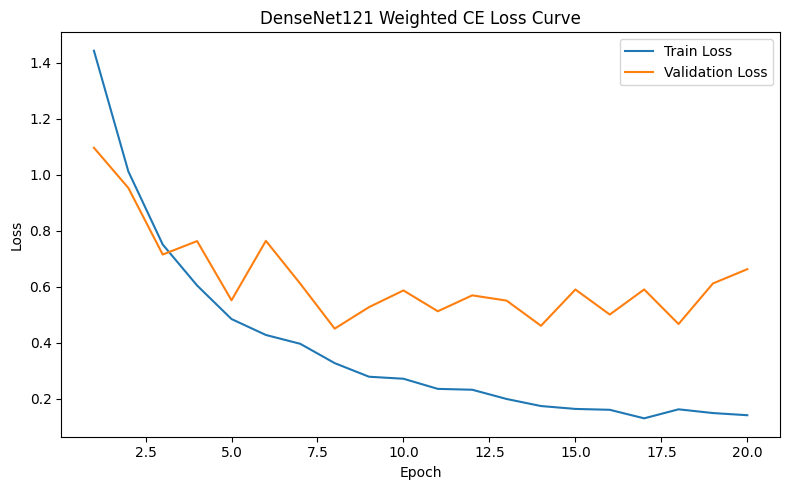

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_weighted_ce_loss_curve.png


In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 Weighted CE Loss Curve")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_loss_curve.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


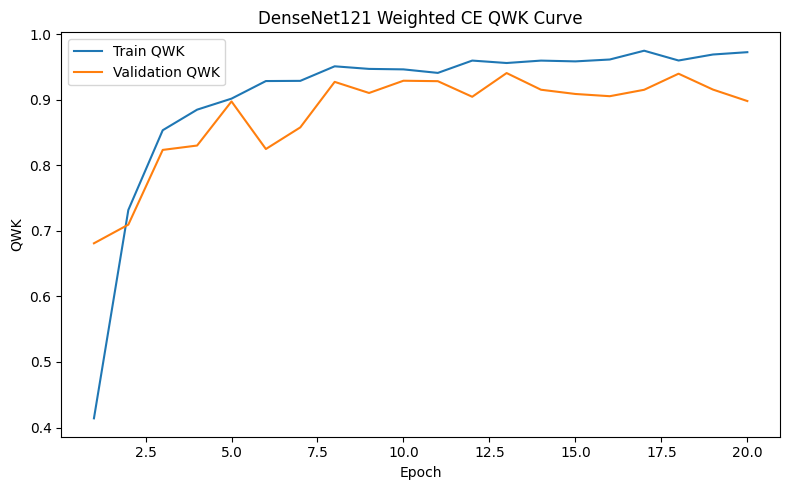

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_weighted_ce_qwk_curve.png


In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_qwk"], label="Train QWK")
plt.plot(history_df["epoch"], history_df["val_qwk"], label="Validation QWK")

plt.xlabel("Epoch")
plt.ylabel("QWK")
plt.title("DenseNet121 Weighted CE QWK Curve")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_qwk_curve.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


In [14]:
test_loss, test_metrics, test_true, test_pred = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print("Test loss:", test_loss)
print_metrics(test_metrics, title="Weighted CE Test Metrics")


Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Test loss: 0.7253841317835308
Weighted CE Test Metrics
accuracy: 0.7381
macro_f1: 0.7293
weighted_f1: 0.7436
mae: 0.3435
qwk: 0.8468
total_errors: 77
adjacent_errors: 59
distant_errors: 18
total_error_rate: 0.2619
adjacent_error_rate: 0.2007
distant_error_rate: 0.0612


In [15]:
test_metrics_df = pd.DataFrame([{
    "experiment": EXPERIMENT_NAME,
    "loss": test_loss,
    **test_metrics
}])

test_metrics_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_test_metrics.csv"
test_metrics_df.to_csv(test_metrics_path, index=False)

test_metrics_df


,experiment,loss,accuracy,macro_f1,weighted_f1,mae,qwk,total_errors,adjacent_errors,distant_errors,total_error_rate,adjacent_error_rate,distant_error_rate
0,densenet121_weighted_ce,0.725384,0.738095,0.729254,0.743621,0.343537,0.846753,77,59,18,0.261905,0.20068,0.061224


In [16]:
from sklearn.metrics import classification_report

report_dict = classification_report(
    test_true,
    test_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_classification_report.csv"
report_df.to_csv(report_path)

report_df


,precision,recall,f1-score,support
0Normal,0.905405,0.736264,0.812121,91.000000
1Doubtful,0.654545,0.818182,0.727273,88.000000
2Mild,0.477273,0.552632,0.512195,38.000000
3Moderate,0.805556,0.828571,0.816901,35.000000
4Severe,0.933333,0.666667,0.777778,42.000000
accuracy,0.738095,0.738095,0.738095,0.738095
macro avg,0.755222,0.720463,0.729254,294.000000
weighted avg,0.767084,0.738095,0.743621,294.000000


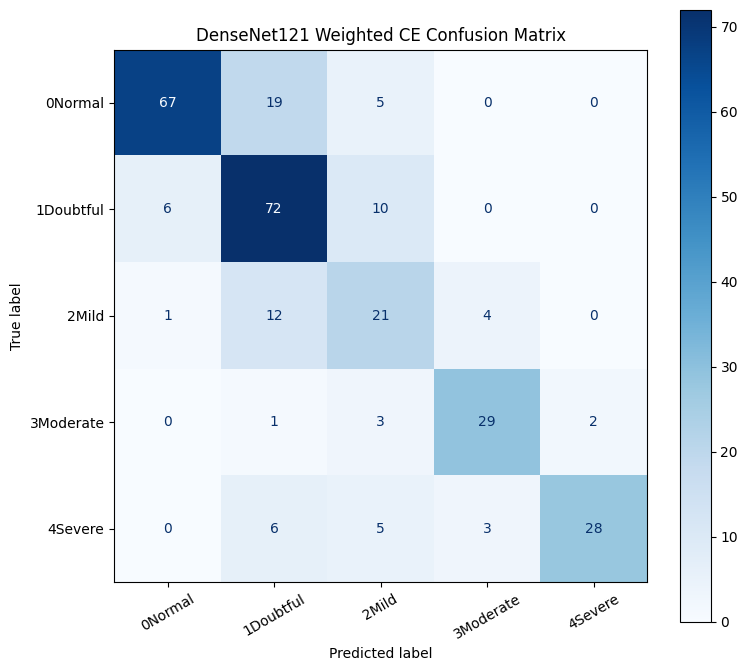

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_weighted_ce_confusion_matrix.png


In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = get_confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("DenseNet121 Weighted CE Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_confusion_matrix.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


In [18]:
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in class_names],
    columns=[f"Pred_{c}" for c in class_names],
)

cm_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_confusion_matrix.csv"
cm_df.to_csv(cm_path)

cm_df


,Pred_0Normal,Pred_1Doubtful,Pred_2Mild,Pred_3Moderate,Pred_4Severe
True_0Normal,67,19,5,0,0
True_1Doubtful,6,72,10,0,0
True_2Mild,1,12,21,4,0
True_3Moderate,0,1,3,29,2
True_4Severe,0,6,5,3,28


In [19]:
test_true_arr = np.array(test_true)
test_pred_arr = np.array(test_pred)

error_distance = np.abs(test_true_arr - test_pred_arr)

error_summary = {
    "experiment": EXPERIMENT_NAME,
    "total_samples": len(test_true_arr),
    "correct": int(np.sum(error_distance == 0)),
    "adjacent_errors": int(np.sum(error_distance == 1)),
    "distant_errors": int(np.sum(error_distance >= 2)),
    "max_error_distance": int(np.max(error_distance)),
    "mae": float(np.mean(error_distance)),
}

error_summary_df = pd.DataFrame([error_summary])

error_summary_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_error_distance.csv"
error_summary_df.to_csv(error_summary_path, index=False)

error_summary_df




,experiment,total_samples,correct,adjacent_errors,distant_errors,max_error_distance,mae
0,densenet121_weighted_ce,294,217,59,18,3,0.343537


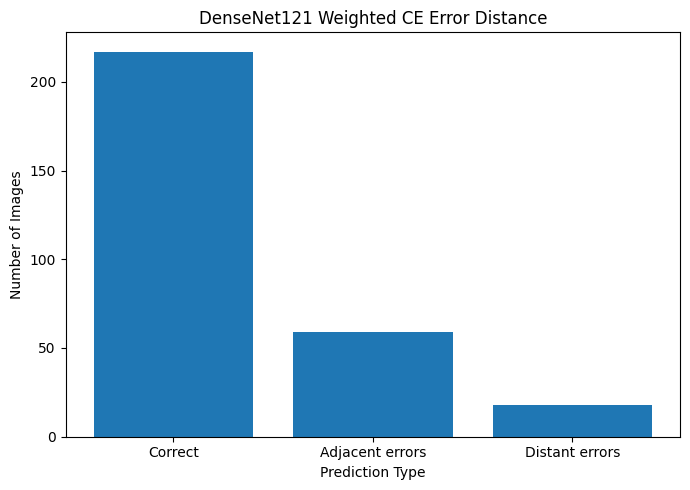

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_weighted_ce_error_distance.png


,error_type,count
0,Correct,217
1,Adjacent errors,59
2,Distant errors,18


In [20]:
error_distance_plot_df = pd.DataFrame([
    {"error_type": "Correct", "count": error_summary["correct"]},
    {"error_type": "Adjacent errors", "count": error_summary["adjacent_errors"]},
    {"error_type": "Distant errors", "count": error_summary["distant_errors"]},
])

plt.figure(figsize=(7, 5))

plt.bar(error_distance_plot_df["error_type"], error_distance_plot_df["count"])

plt.xlabel("Prediction Type")
plt.ylabel("Number of Images")
plt.title("DenseNet121 Weighted CE Error Distance")
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_error_distance.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

error_distance_plot_df
